 # 04 - 发育轨迹推断 (Trajectory Inference)
 
 目标：
 1. PAGA 构建细胞类型间的过渡图
 2. Diffusion Map 降维捕捉非线性分化流形
 3. Diffusion Pseudotime 推断分化方向
 4. 将伪时间映射到 UMAP，观察分化连续性

## 1. 加载带注释的数据

In [15]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

from src import config
from src.io import load_h5ad, save_h5ad
from src.trajectory import run_paga, run_diffmap, run_dpt

In [16]:
adata = load_h5ad("pbmc3k_annotated.h5ad")
print(f"数据: {adata.n_obs} 细胞 × {adata.n_vars} 基因")
print(f"细胞类型: {adata.obs['cell_type'].cat.categories.tolist()}")

数据: 2638 细胞 × 2000 基因
细胞类型: ['T cells', 'Monocytes', 'NK cells', 'B cells', 'Dendritic cells', 'Platelets']


## 2. PAGA：细胞类型过渡图

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])


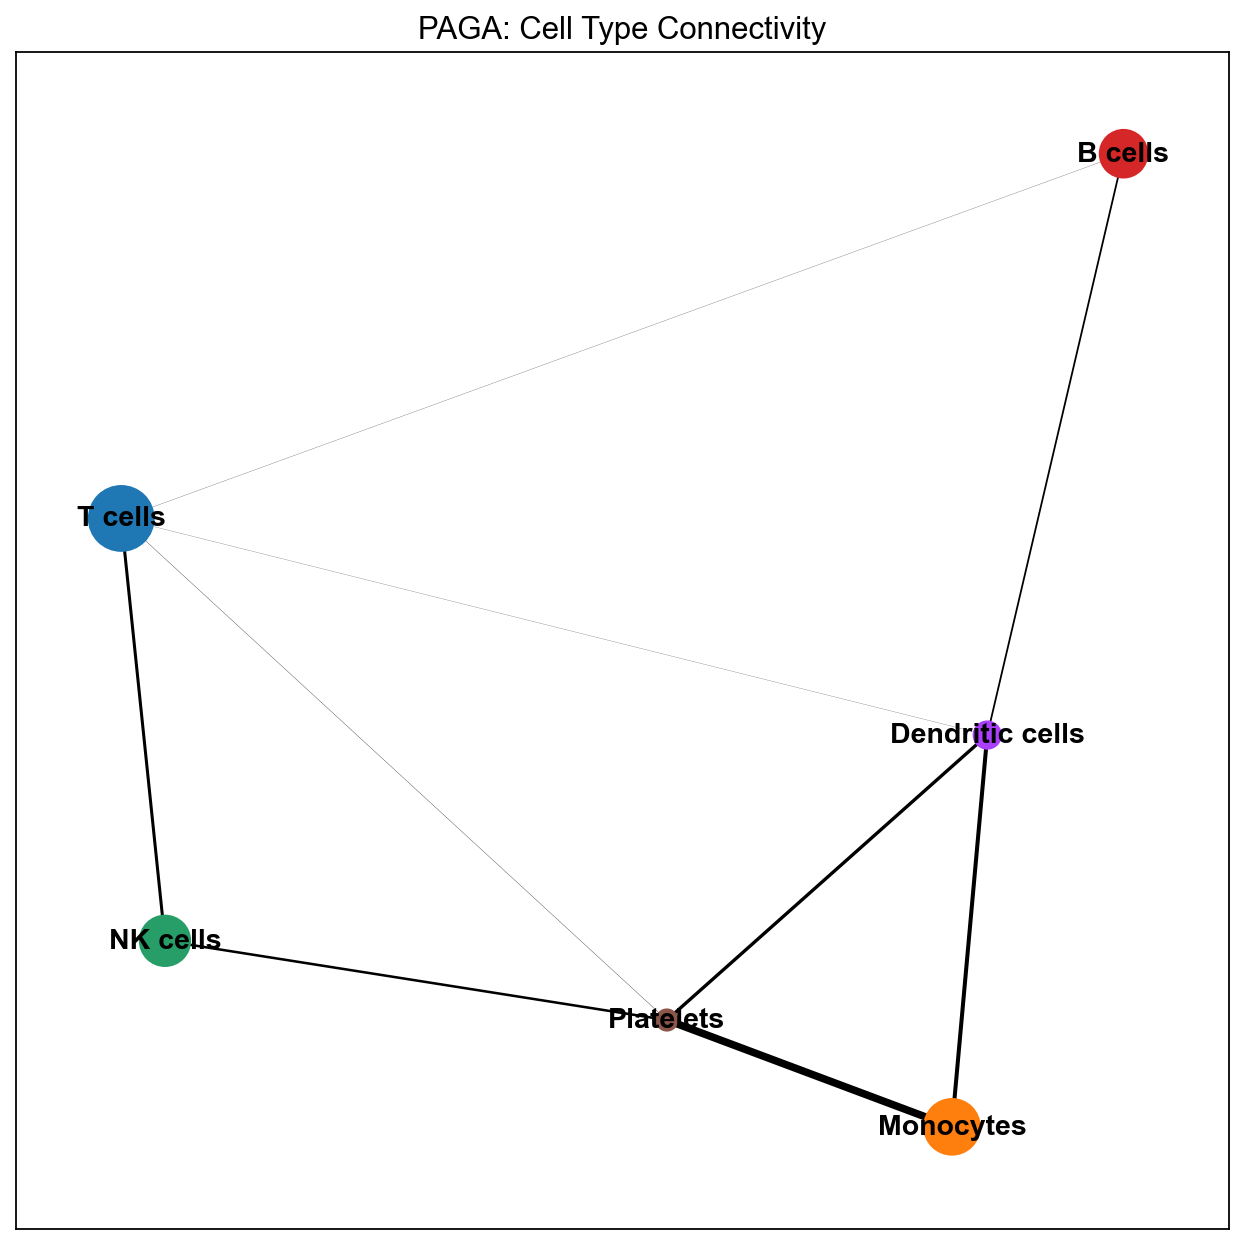

In [17]:
# PAGA 需要基于 neighbor graph，我们在 Phase 2 已经构建好了
run_paga(adata, groups="cell_type")

# 绘制 PAGA 图
fig, ax = plt.subplots(figsize=(8, 8))
sc.pl.paga(
    adata,
    color="cell_type",
    node_size_scale=3,
    edge_width_scale=1,
    ax=ax,
    show=False,
    title="PAGA: Cell Type Connectivity"
)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_paga_graph.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# 打印连接强度
print("\nPAGA 连接权重（过渡概率）:")

connectivities = adata.uns["paga"]["connectivities"]

# 稀疏矩阵先转 dense
import numpy as np
if hasattr(connectivities, "toarray"):
    connectivities = connectivities.toarray()
elif hasattr(connectivities, "todense"):
    connectivities = np.array(connectivities.todense())

connectivities = np.asarray(connectivities)
print(f"矩阵形状: {connectivities.shape}")

# 获取 PAGA 实际使用的类别顺序
paga_groups = adata.uns["paga"].get("groups", "cell_type")
if isinstance(paga_groups, str) and paga_groups in adata.obs.columns:
    ct_order = adata.obs[paga_groups].cat.categories.tolist()
else:
    ct_order = [str(i) for i in range(connectivities.shape[0])]

# 如果形状还是不对，回退到 leiden 顺序
if connectivities.shape[0] != len(ct_order):
    ct_order = adata.obs["leiden"].cat.categories.tolist()

try:
    conn_df = pd.DataFrame(connectivities, index=ct_order, columns=ct_order)
    print(conn_df.round(3))
except ValueError as e:
    print(f"无法构建方阵: {e}")
    print("原始连接数据:")
    print(connectivities.round(3))


PAGA 连接权重（过渡概率）:
矩阵形状: (6, 6)
                 T cells  Monocytes  NK cells  B cells  Dendritic cells  \
T cells            0.000      0.000     0.182    0.013            0.011   
Monocytes          0.000      0.000     0.001    0.001            0.242   
NK cells           0.182      0.001     0.000    0.002            0.000   
B cells            0.013      0.001     0.002    0.000            0.107   
Dendritic cells    0.011      0.242     0.000    0.107            0.000   
Platelets          0.018      0.453     0.153    0.000            0.201   

                 Platelets  
T cells              0.018  
Monocytes            0.453  
NK cells             0.153  
B cells              0.000  
Dendritic cells      0.201  
Platelets            0.000  


### 解读 PAGA 图
 
 - **节点大小** = 该细胞类型的细胞数
 - **边粗细** = 两个细胞类型之间的转录组相似度/过渡概率
 - **预期结果**：T cells ↔ NK cells 应该有强连接（共享淋巴系起源），Monocytes ↔ DC 应该有连接（共享髓系起源）


## 3. Diffusion Map 降维

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9988568  0.99423903 0.9733579  0.9647974  0.96018267
     0.95536995 0.8927389  0.8903876  0.86168605 0.8507892  0.82251406
     0.8171526  0.81260854 0.7841539 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)


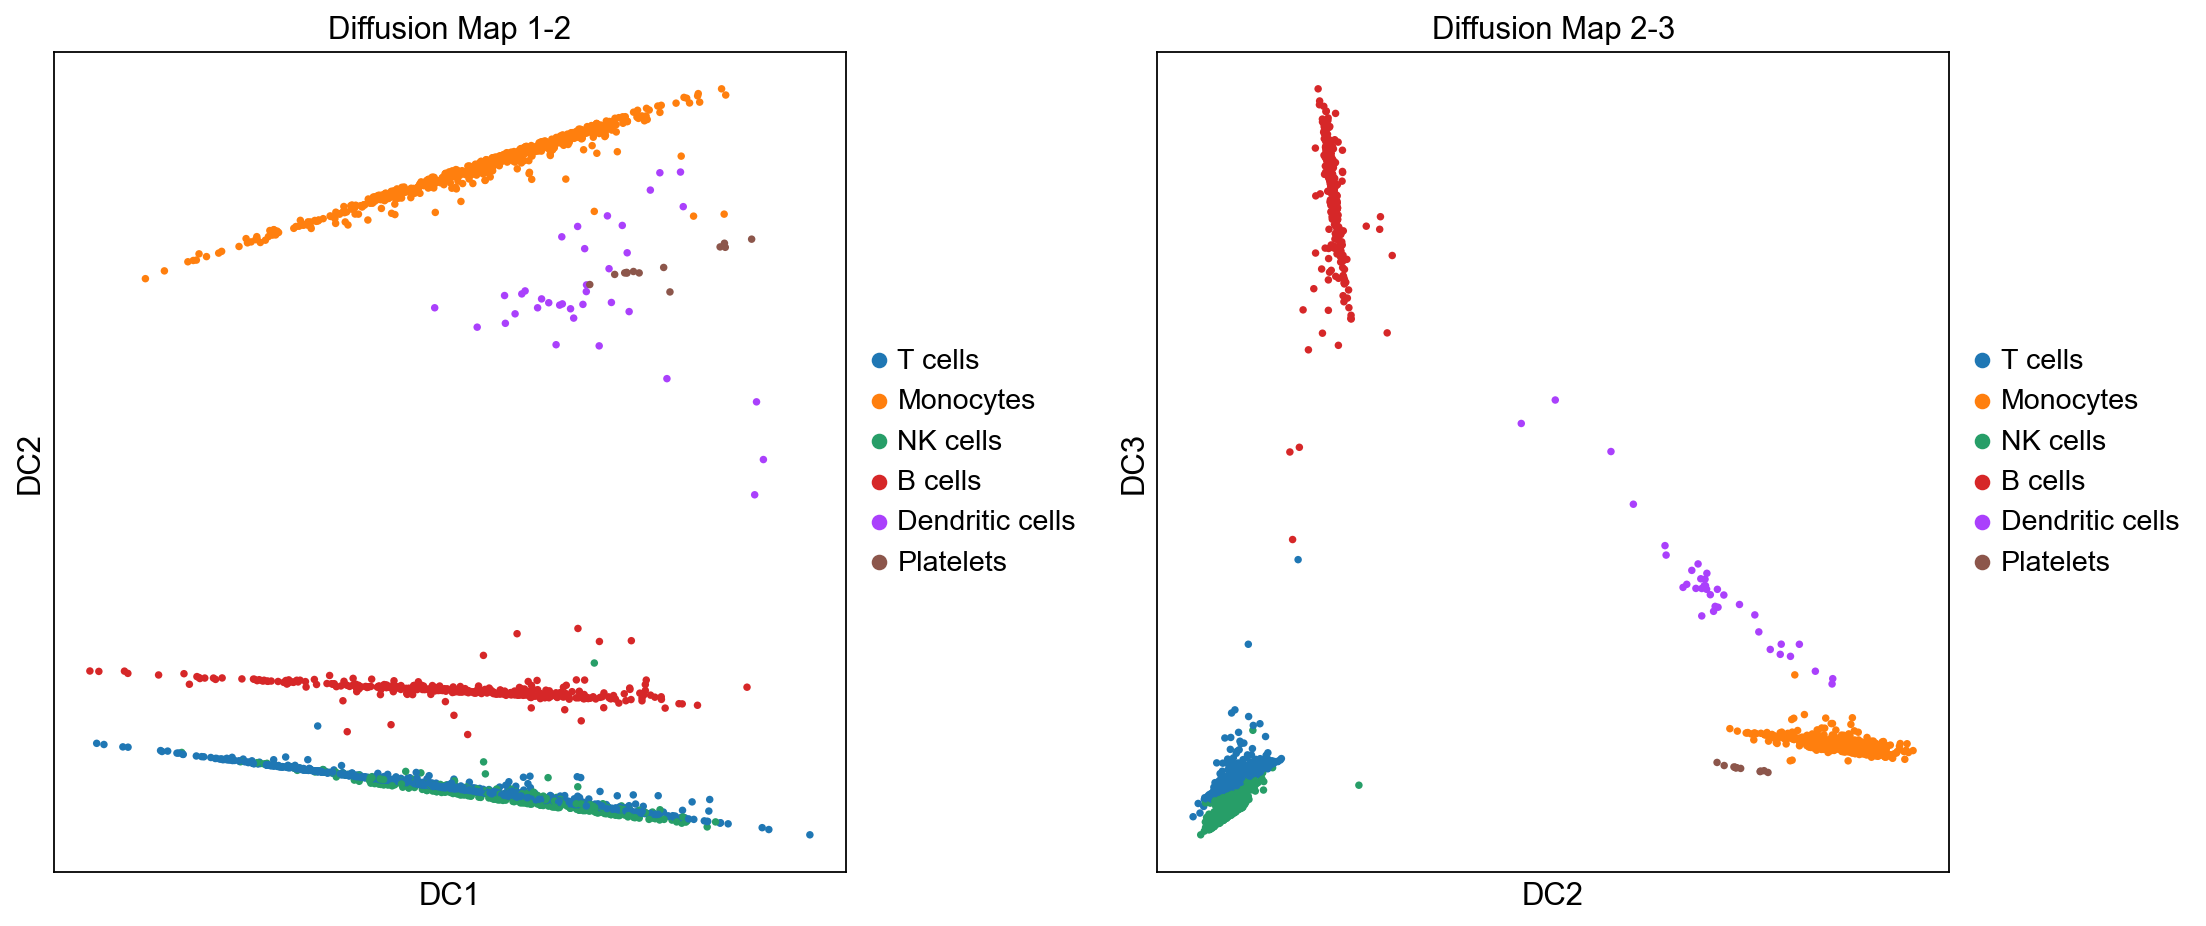

In [19]:
run_diffmap(adata, n_comps=15)

# 可视化 Diffusion Map（前3个成分）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.diffmap(adata, color="cell_type", components=["1,2"], ax=axes[0], show=False, title="Diffusion Map 1-2")
sc.pl.diffmap(adata, color="cell_type", components=["2,3"], ax=axes[1], show=False, title="Diffusion Map 2-3")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_diffmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Diffusion Pseudotime（DPT）

In [20]:
# 以 T cells 作为分化起点（淋巴系祖细胞方向）
# 注意：PBMC 是成熟免疫细胞，这里的"分化"更多是指激活/状态转换，而非严格发育
run_dpt(adata, root_group="T cells", root_key="cell_type")

# 查看伪时间分布
print("伪时间统计:")
print(adata.obs["dpt_pseudotime"].describe())

computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)
伪时间统计:
count    2638.000000
mean        0.280767
std         0.366239
min         0.000000
25%         0.017323
50%         0.045610
75%         0.743204
max         1.000000
Name: dpt_pseudotime, dtype: float64


# 5. 可视化：伪时间映射到 UMAP + PAGA

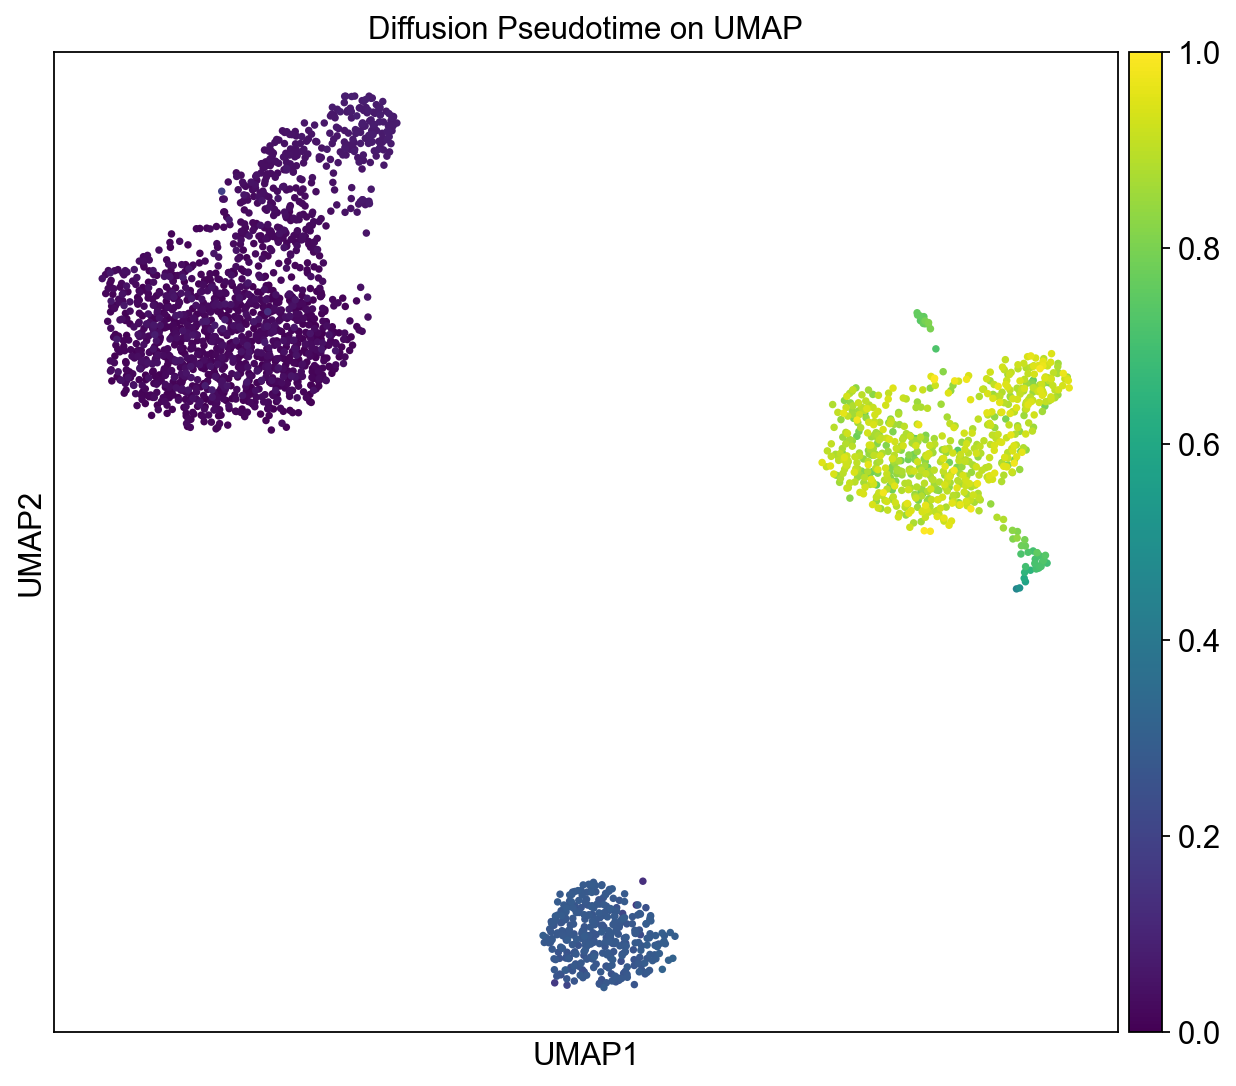

In [21]:
# 5.1 UMAP 上着色伪时间
fig, ax = plt.subplots(figsize=(8, 7))
sc.pl.umap(adata, color="dpt_pseudotime", ax=ax, show=False, 
           title="Diffusion Pseudotime on UMAP", color_map="viridis")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_umap_dpt.png", dpi=150, bbox_inches="tight")
plt.show()

--> added 'pos', the PAGA positions (adata.uns['paga'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_4964\3415937626.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


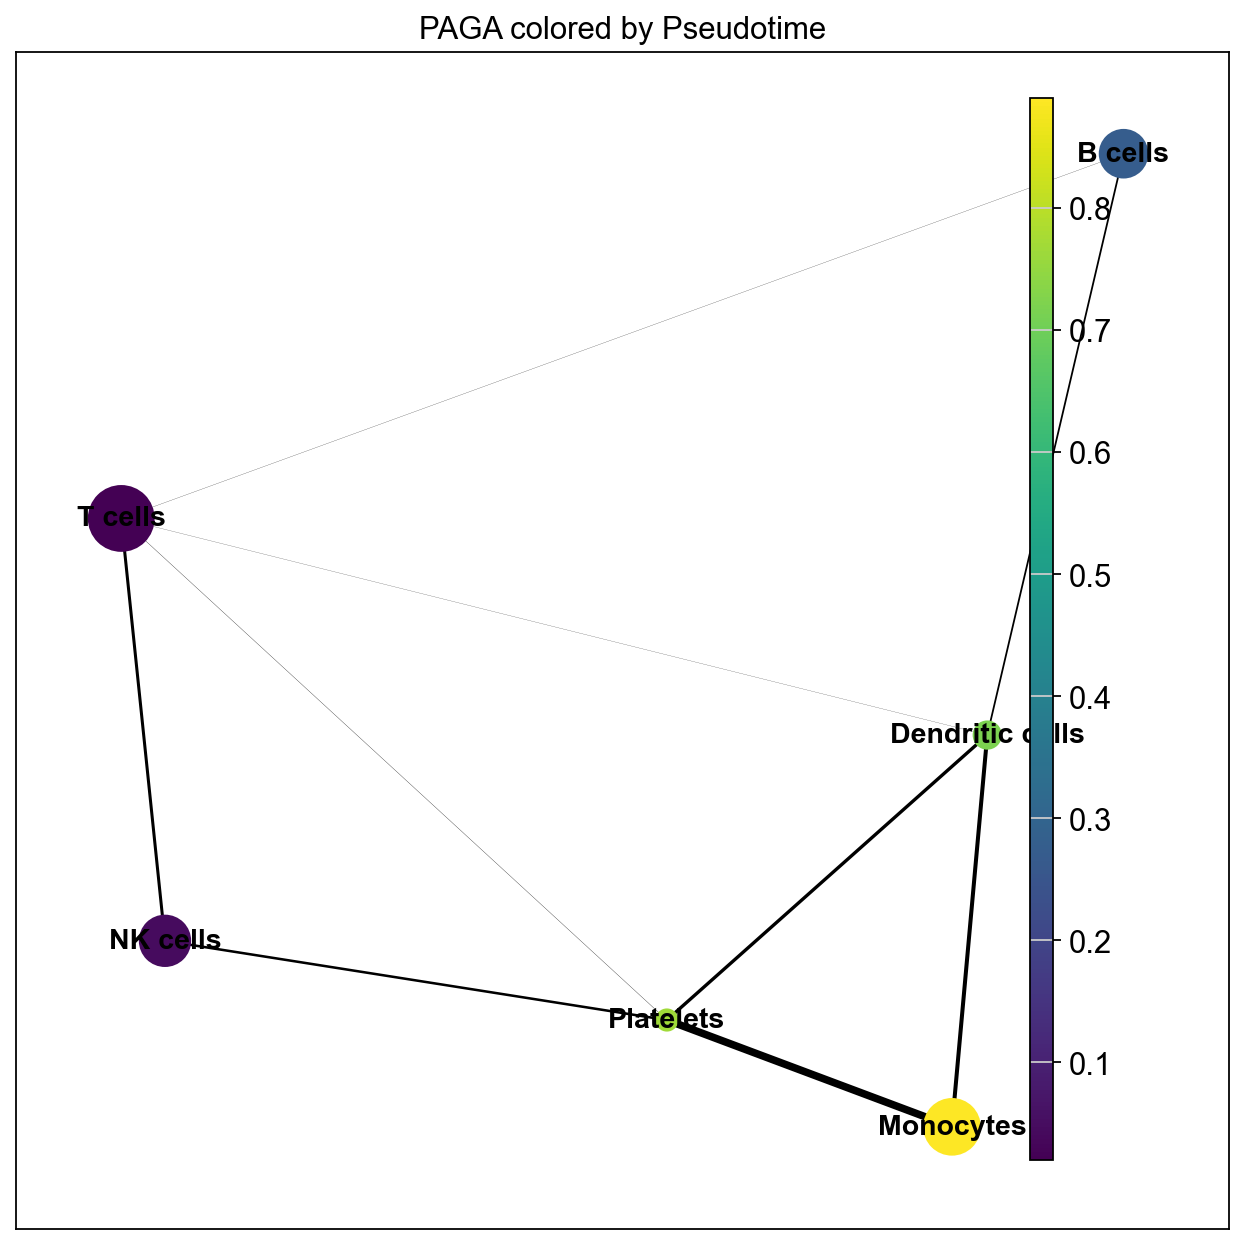

In [22]:
# 5.2 PAGA 上着色伪时间
fig, ax = plt.subplots(figsize=(8, 8))
sc.pl.paga(
    adata,
    color="dpt_pseudotime",
    node_size_scale=3,
    edge_width_scale=1,
    ax=ax,
    show=False,
    title="PAGA colored by Pseudotime"
)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_paga_dpt.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_4964\3926802821.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_4964\3926802821.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


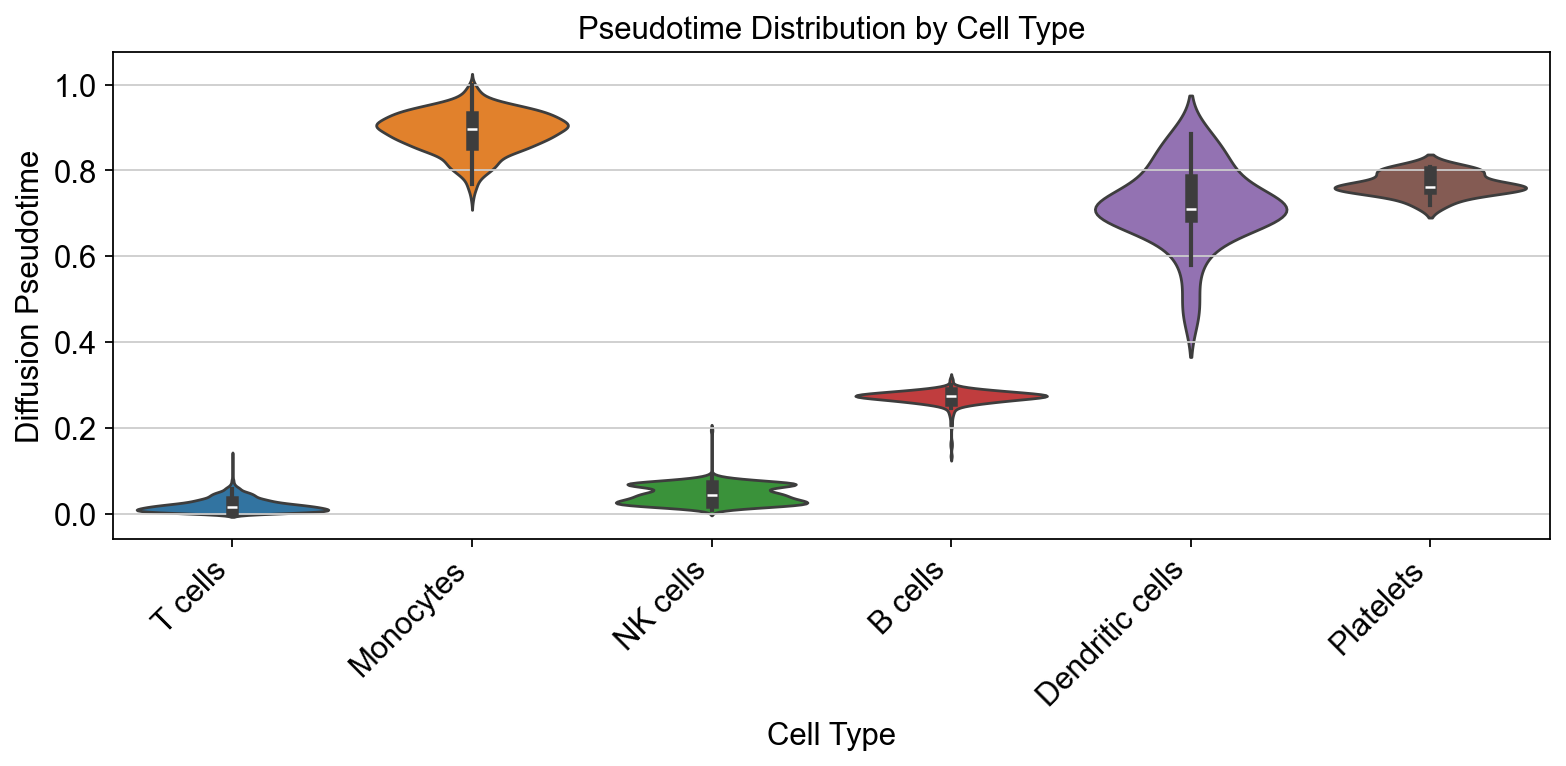

In [23]:
# 5.3 各细胞类型的伪时间箱线图
fig, ax = plt.subplots(figsize=(10, 5))

# 用 seaborn 直接画，绕过 scanpy 的 violin 封装
dpt_df = adata.obs[["cell_type", "dpt_pseudotime"]].copy()

sns.violinplot(
    data=dpt_df,
    x="cell_type",
    y="dpt_pseudotime",
    palette="tab10",
    inner="box",
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Pseudotime Distribution by Cell Type")
ax.set_xlabel("Cell Type")
ax.set_ylabel("Diffusion Pseudotime")

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_dpt_violin.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 拓扑 × 轨迹联合分析
 
问题：拓扑上最独立的 Platelets，在轨迹中处于什么位置？
预期：它们应该有最高的伪时间（离根最远），或者形成一个死端。

In [24]:
# 计算每个细胞类型的平均伪时间
dpt_by_type = adata.obs.groupby("cell_type")["dpt_pseudotime"].agg(["mean", "std", "count"])
print("\n各细胞类型平均伪时间:")
print(dpt_by_type.round(3))

# 与拓扑持久性联合
topo_stats = pd.read_csv(config.TABLES_DIR / "02_cluster_topology_stats.csv")
topo_stats["cell_type"] = topo_stats["cluster"].astype(str).map(
    dict(zip(adata.obs["leiden"].cat.categories.astype(str), 
             adata.obs.groupby("leiden")["cell_type"].first()))
)

merged = topo_stats.merge(
    dpt_by_type.reset_index(), 
    on="cell_type", 
    how="left"
)


各细胞类型平均伪时间:
                  mean    std  count
cell_type                           
T cells          0.020  0.015   1181
Monocytes        0.890  0.046    639
NK cells         0.046  0.021    427
B cells          0.272  0.017    342
Dendritic cells  0.719  0.092     36
Platelets        0.768  0.025     13


C:\Users\Admin\AppData\Local\Temp\ipykernel_4964\4012864260.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dpt_by_type = adata.obs.groupby("cell_type")["dpt_pseudotime"].agg(["mean", "std", "count"])
C:\Users\Admin\AppData\Local\Temp\ipykernel_4964\4012864260.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("leiden")["cell_type"].first()))


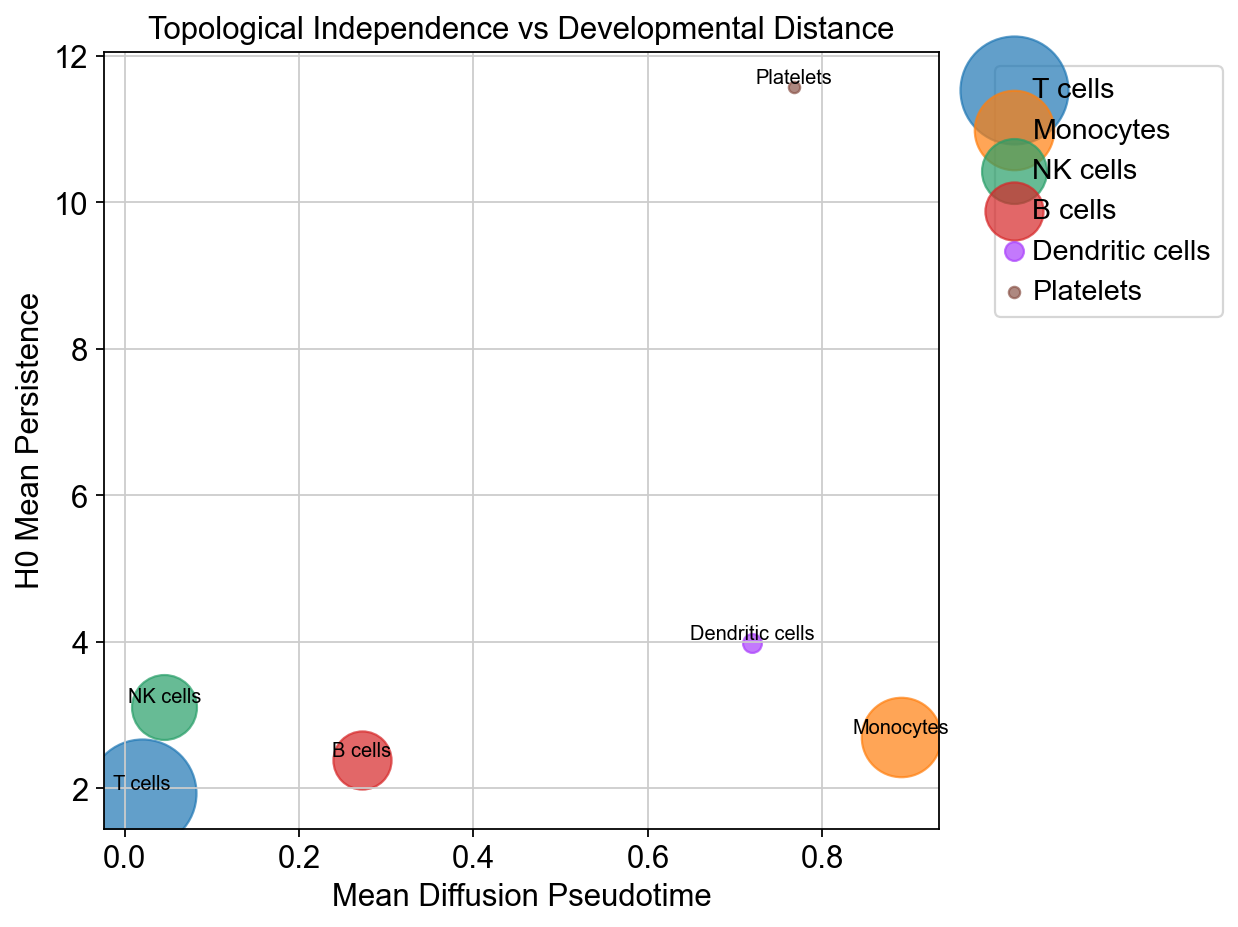

In [25]:
# 可视化：拓扑持久性 vs 伪时间
fig, ax = plt.subplots(figsize=(8, 6))
for ct in merged["cell_type"]:
    row = merged[merged["cell_type"] == ct].iloc[0]
    ax.scatter(row["mean"], row["mean_persistence_h0"], s=row["count"]*2, 
               alpha=0.7, label=ct)
    ax.annotate(ct, (row["mean"], row["mean_persistence_h0"]), 
                fontsize=9, ha="center", va="bottom")

ax.set_xlabel("Mean Diffusion Pseudotime")
ax.set_ylabel("H0 Mean Persistence")
ax.set_title("Topological Independence vs Developmental Distance")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_topo_vs_dpt.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 保存最终数据

In [26]:
save_h5ad(adata, "pbmc3k_final.h5ad")
print("最终数据已保存，包含所有分析结果")

最终数据已保存，包含所有分析结果
